<a href="https://colab.research.google.com/github/anyuanay/INFO323/blob/main/INFO323_Lecture_week3_GCP_BigQuery_AI_Platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="text-align:center"> INFO 323: Cloud Computing and Big Data</h1>
<h2 style="text-align:center"> College of Computing and Informatics</h2>
<h2 style="text-align:center">Drexel University</h2>

<h3 style="text-align:center"> Exploratory Data Analysis using BigQuery on Flights Data</h3>
<h3 style="text-align:center"> Yuan An, PhD</h3>
<h3 style="text-align:center">Associate Professor</h3>

Reference: Data Science on the Google Cloud Platform. Valliappa Lakshmanan. O'Reilly, 2ed, April 2022

Ch5. Interactive Data Exploration

In [ ]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from google.cloud import bigquery

In [ ]:
# Initialize the client
# project_id = 'YOUR PROJECT ID'

project_id = 'info323-spring2026-ya45' # this is my project id, not yours

bq = bigquery.Client(project=project_id)

## Data Ingest:
### You should have downloaded and ingested the flight data for a year to BigQuery
### Is your table name "flights-2023" or something else? Ensure to use the table name you created.
### In my case, the table name is "flights" which is under the dataset "dsongcp".

## BigQuery from Python

```
sql = """
SELECT
  COUNTIF(ArrDelay >= 15)/COUNT(ArrDelay) AS frac_delayed
FROM `dsongcp.flights-2023`
"""

df = bq.query(sql).to_dataframe()
print(df)
```

# Exploratory Data Analysis

Here are the thoughts of the EDA to develop a simple model with explanatory power:
- List the unique origin and destination airports
- Explor the arrival and departure delays. Some questions to answer:
     - How are the arrival delays distributed if a flight is late for certain time, for example, 10 minutes?
     - What are the average departure and arrival delays for each airport? Should we pay attention to every airport?
     - What is the percentage of delayed flights in the data set?
     - How are the departure delays and arrival delays distributed overall?
     - Do the arrival delays of ontime flights differ significantly from the arrival delays of the flights that were delayed?
     - For each departure delay, we want to know how the associated arrival delays are distributed.
     - For each departure delay, can we infer the arrival deplay with > 70% probability?
     - Overall, the EDA should tell us at which departure delay, the flight would not be on-time with > 70% probability.
     - How does the simple model perform? Can we evalute it using the data in a different year?

## List the Origin and Desitnation Airports and Number of Flights
- list the unique origin airports and number of flights
- list the unique destination airports and number of flights.

```
sql = """
SELECT
  Origin,
  count(*) as num_flights
FROM `dsongcp.flights-2023`
Group by Origin
Order by num_flights desc
"""

df = bq.query(sql).to_dataframe()
print(df)
```

```
df.shape
```

```
(df.num_flights < 3650).sum()
```

## How are the arrival deplays distributed over the year?
Find the arrival delay for flights that depart more than 10 minutes late. If we put the results in a Pandas DataFrame, we can get the basis statistics using Pandas DataFrame describe().

```
sql = """
select arrdelay
from `dsongcp.flights-2023`
where arrdelay > 10
"""

df = bq.query(sql).to_dataframe()
```

```
df.describe()
```

## Let us visualize the ArrDelays for DepDelay > 10 minutes
- Plot a violin plot of the arrival delay for flights that depart more than 10 minutes late.
- What does the violin plot tell us?

<Axes: xlabel='arrdelay'>

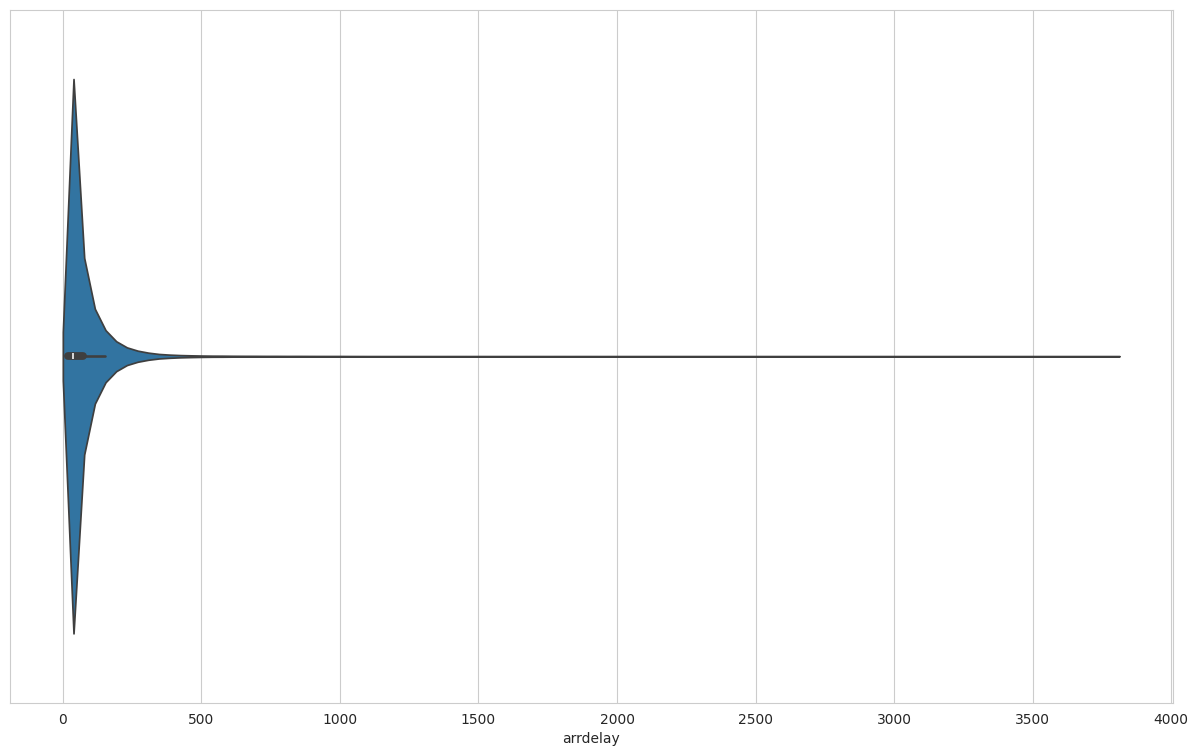

In [ ]:
plt.figure(figsize=(15, 9))
sns.set_style("whitegrid")
sns.violinplot(data=df, x="arrdelay", inner='box', orient='landscape')

## What are the average departure and arrival delay at each (origin) airport?
Find average departure and arrival delays at each airport (origin) in the US.

We will retain only airports where there were at least 365 flights (at least 1 flights per day), and sort them by departure delay in descending order.

## What is the percentage of delayed flights?
Assume a flight is delayed if its arrival delay was more than 15 minutes. Find the percentage of the delayed flights.

## Which origin airport has the most number of delayed flights?
For each origin airport, calculate and order the percentage of delayed flights.

Stockton Metropolitan Airport and Tri-State Airport is a public airport in Wayne County, West Virginia are the top 2. Do they have flights all-year around?

## Which pair of origin and destination airports has the most number of delayed flights?
For each pair of origin and destination airports, calculate and order the percentage of delayed flights.

## Which airline has the most delayed flights?

Do airlines perform differently for different origins and destinations?

## How are departure delays related to arrival delays?
For each departure delay, calculate the average arrival delay. How are the average arrival delays coorelated with the departure delays?

<Axes: xlabel='depdelay'>

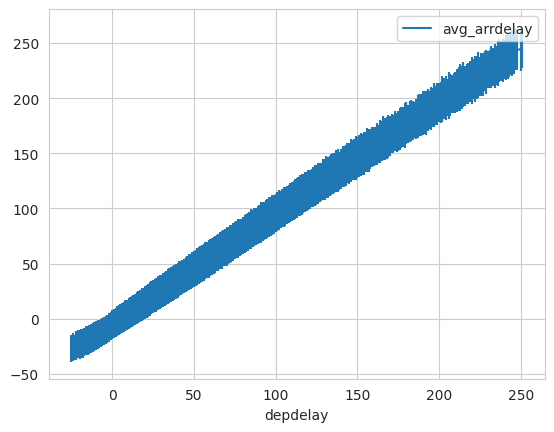

In [ ]:
df.plot(kind='line', x='depdelay', y='avg_arrdelay', yerr='std_arrdelay')

<Axes: xlabel='depdelay'>

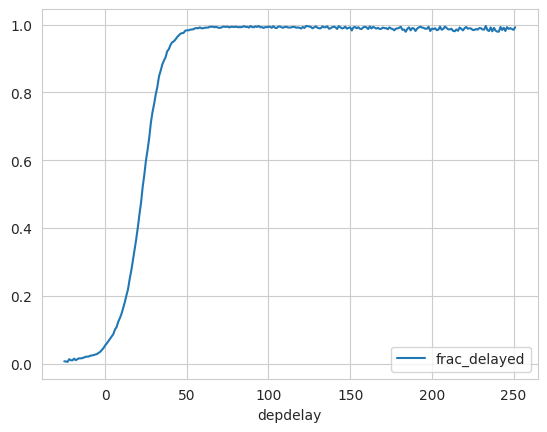

In [ ]:
df.plot(kind='line', x='depdelay', y='frac_delayed')

## For which departure delay, the flight is late
The frac_delayed increases as the depdelay increases. We can find a threshold of depdelay for more than 30% of delayed flights.

In [ ]:
df[(df.frac_delayed > 0.29) & (df.frac_delayed < 0.31)]

,depdelay,avg_arrdelay,std_arrdelay,frac_delayed,num_flights
233,17.0,11.714628,14.623452,0.305627,41014


## Find the decision boundary based on normal distribution assumption:
For each depdelay, there are at least 365 flights. Assume the arrival delays follow the normal distribution for each depdelay. We would like to find that for each depdelay, what is the arrival delay cutoff with the probability of 70%?   

In [ ]:
# The z-score of standard normal distribtuion at 0.7
from scipy.stats import norm

probability = 0.7
z_value = norm.ppf(probability)
print("Z-value:", z_value)

Z-value: 0.5244005127080407


For each depdelay, the mean of the arrival delay distribution is avg_arrdelay and the standard deviation of the distribution is std_arrdelay. To transform the distribution to standard normal distribution, we calcualte the z_score as:
$$
z\_score =\frac{cutoff\_arrdelay - avg\_arrdelay}{std\_arrdelay}
$$
The cutoff_arrdelay is:
$$
cutoff\_arrdelay = avg\_arrdelay + (z\_score \times std\_arrdelay)
$$

In [ ]:
# Calculate the cutoff_arrdelay for each depture delay at 70% probability
df['cutoff_arrdelay'] = df['avg_arrdelay'] + 0.52 * df['std_arrdelay']

In [ ]:
df.head()

,depdelay,avg_arrdelay,std_arrdelay,frac_delayed,num_flights,cutoff_arrdelay
0,251.0,244.473545,16.915317,0.992126,381,253.269510
1,250.0,244.642857,20.337392,0.984375,384,255.218301
2,248.0,243.685185,18.084647,0.989529,382,253.089202
3,247.0,244.466495,18.529296,0.987277,393,254.101729
4,246.0,243.686076,21.878708,0.992462,398,255.063004


## Find the departure delay at which there is more than 70% probability that the arrival delay is more than 15 minutes

In [ ]:
df[(df.cutoff_arrdelay > 14) & (df.cutoff_arrdelay < 16)]

,depdelay,avg_arrdelay,std_arrdelay,frac_delayed,num_flights,cutoff_arrdelay
236,14.0,8.484614,14.173304,0.218678,49383,15.854732
237,13.0,7.416966,14.241686,0.200439,51986,14.822643


According the above analysis, if the flight is delayed more than 13 minutes at departure, there is more than 70% chance that the flight will be late (arrival delayed more than 15 minutes.)

## Evaluation
- We should verify the precision and recall of the model by using the flight data in a different year.
- We can also build model based on the origin and destination.